# PROJECT BUSINESS UNDERSTANDING  
## Port Trade Disruption Early-Warning System for Kenya

### BUSINESS PROBLEM  
Kenya’s economy depends heavily on port activity, particularly at Mombasa and Lamu. When port operations are disrupted, the effects spread quickly across trade, fuel supply, manufacturing, and food distribution. Current responses are mostly reactive, meaning that stakeholders often act only after losses and delays have already occurred.

### PROBLEM STATEMENT  
This project develops a machine learning early-warning system that predicts significant port trade disruptions using daily port operations data. Its purpose is to provide advance risk signals that can help stakeholders respond earlier, strengthen logistics resilience, and support better decision-making.

### STAKEHOLDERS  
**Kenya Ports Authority:** For operational monitoring and early intervention.  
**Government Agencies:** For trade, customs, and economic response planning.  
**Importers and Exporters:** For shipment and supply chain adjustment.  
**Manufacturers and Retailers:** For production and inventory planning.  
**Consumers:** As indirect beneficiaries of improved supply stability.



| Disruption Type         | What Happens                                      | Example from Data                                                                 | Impact                                      |
|------------------------|--------------------------------------------------|----------------------------------------------------------------------------------------|---------------------------------------------|
| Demand-side disruption | Fewer vessels arrive → cargo volume drops        | COVID-19 (April 2020): Mombasa went from 5–7 port calls/day to 1–2 calls/day           | Importers wait weeks for goods*              |
| Supply-side disruption | Vessels arrive but cannot unload → cargo piles up| Congestion event (Dec 2025): 28 vessels waiting to berth                               | Perishable goods rot, demurrage costs explode |

A disruption occurs when daily cargo throughput (import + export tonnes) falls below 50% of its 30-day rolling average OR when berth occupancy exceeds 90% for 3 consecutive days.

# Section 1: Environment Setup

## 1.1 Import Core Libraries


In [302]:
# Data manipulation
import pandas as pd
import numpy as np

# Date handling
from datetime import datetime, timedelta

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Machine Learning


# Explainability


# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Section 2: Data Understanding and Cleaning

## 2.1 Data loading

In [303]:
df_port = pd.read_csv("data/port_activity_data.csv")
df_turn = pd.read_csv("data/SHIP TURN AROUND TIME.csv")
df_wait = pd.read_csv("data/SHIP WAITING TIME.csv")
print(f"Port daily activities: {df_port.shape[0]} rows {df_port.shape[1]} columns")
print(f"Vessel turn around time: {df_turn.shape[0]} rows {df_turn.shape[1]} columns")
print(f"Vessel waiting time: {df_wait.shape[0]} rows {df_wait.shape[1]} columns")

Port daily activities: 5300 rows 29 columns
Vessel turn around time: 241 rows 5 columns
Vessel waiting time: 245 rows 5 columns


## 2.2 Port activities data understanding

In [304]:
#port activities columns names
print(df_port.columns.T)

Index(['date', 'year', 'month', 'day', 'portid', 'portname', 'country', 'ISO3',
       'portcalls_container', 'portcalls_dry_bulk', 'portcalls_general_cargo',
       'portcalls_roro', 'portcalls_tanker', 'portcalls_cargo', 'portcalls',
       'import_container', 'import_dry_bulk', 'import_general_cargo',
       'import_roro', 'import_tanker', 'import_cargo', 'import',
       'export_container', 'export_dry_bulk', 'export_general_cargo',
       'export_roro', 'export_tanker', 'export_cargo', 'export'],
      dtype='object')


In [305]:
#port activities column data type
print(df_port.dtypes)

date                       object
year                        int64
month                       int64
day                         int64
portid                     object
portname                   object
country                    object
ISO3                       object
portcalls_container         int64
portcalls_dry_bulk          int64
portcalls_general_cargo     int64
portcalls_roro              int64
portcalls_tanker            int64
portcalls_cargo             int64
portcalls                   int64
import_container            int64
import_dry_bulk             int64
import_general_cargo        int64
import_roro                 int64
import_tanker               int64
import_cargo                int64
import                      int64
export_container            int64
export_dry_bulk             int64
export_general_cargo        int64
export_roro                 int64
export_tanker               int64
export_cargo                int64
export                      int64
dtype: object


In [306]:
#port activities sample data
df_port.head()

,date,year,month,day,portid,portname,country,ISO3,portcalls_container,portcalls_dry_bulk,...,import_tanker,import_cargo,import,export_container,export_dry_bulk,export_general_cargo,export_roro,export_tanker,export_cargo,export
0,2026-04-03 00:00:00+00:00,2026,4,3,port631,Lamu,Kenya,KEN,1,0,...,0,15633,15633,0,0,0,0,0,0,0
1,2026-04-03 00:00:00+00:00,2026,4,3,port757,Mombasa,Kenya,KEN,2,0,...,0,24577,24577,1370,0,1910,0,0,3280,3280
2,2026-04-02 00:00:00+00:00,2026,4,2,port631,Lamu,Kenya,KEN,1,0,...,0,0,0,3711,0,0,0,0,3711,3711
3,2026-04-02 00:00:00+00:00,2026,4,2,port757,Mombasa,Kenya,KEN,1,1,...,66065,40876,106941,685,1327,0,0,509,2012,2522
4,2026-04-01 00:00:00+00:00,2026,4,1,port631,Lamu,Kenya,KEN,2,0,...,0,3567,3567,1697,0,0,0,0,1697,1697


In [307]:
df_port["date"].max()

'2026-04-03 00:00:00+00:00'

In [308]:
#date range
print(f"Date ranges from: {df_port['date'].min()} - {df_port['date'].max()}")

Date ranges from: 2019-01-01 00:00:00+00:00 - 2026-04-03 00:00:00+00:00


In [309]:
# missing values
missing = df_port.isnull().sum()
missing[missing >0]

Series([], dtype: int64)

In [310]:
# duplicate rows
df_port.duplicated().sum()

0

In [311]:
#statistical analysis
df_port.describe()

,year,month,day,portcalls_container,portcalls_dry_bulk,portcalls_general_cargo,portcalls_roro,portcalls_tanker,portcalls_cargo,portcalls,...,import_tanker,import_cargo,import,export_container,export_dry_bulk,export_general_cargo,export_roro,export_tanker,export_cargo,export
count,5300.000000,5300.000000,5300.000000,5300.000000,5300.000000,5300.000000,5300.000000,5300.000000,5300.000000,5300.000000,...,5300.000000,5300.000000,5300.000000,5300.000000,5300.000000,5300.000000,5300.000000,5300.000000,5300.000000,5300.000000
mean,2022.140377,6.366038,15.708679,0.795849,0.460189,0.337547,0.180189,0.400000,1.773774,2.173774,...,13855.328302,19797.734151,33653.178868,563.190189,517.922264,239.606038,3.656038,288.545283,1324.403774,1612.975849
std,2.098156,3.489987,8.805699,1.102683,0.721518,0.583333,0.438934,0.707974,1.881855,2.267660,...,31229.992070,30648.221913,49771.260482,2097.754532,4647.114916,809.947318,79.341149,2742.017945,5275.932187,5967.193499
min,2019.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2020.000000,3.000000,8.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2022.000000,6.000000,16.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,0.000000,0.000000,56.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2024.000000,9.000000,23.000000,1.000000,1.000000,1.000000,0.000000,1.000000,3.000000,4.000000,...,0.000000,32015.000000,57044.750000,0.000000,0.000000,0.000000,0.000000,0.000000,685.000000,955.000000
max,2026.000000,12.000000,31.000000,7.000000,7.000000,5.000000,4.000000,5.000000,19.000000,24.000000,...,234228.000000,306828.000000,541056.000000,30691.000000,108624.000000,10793.000000,3921.000000,111941.000000,109168.000000,111941.000000


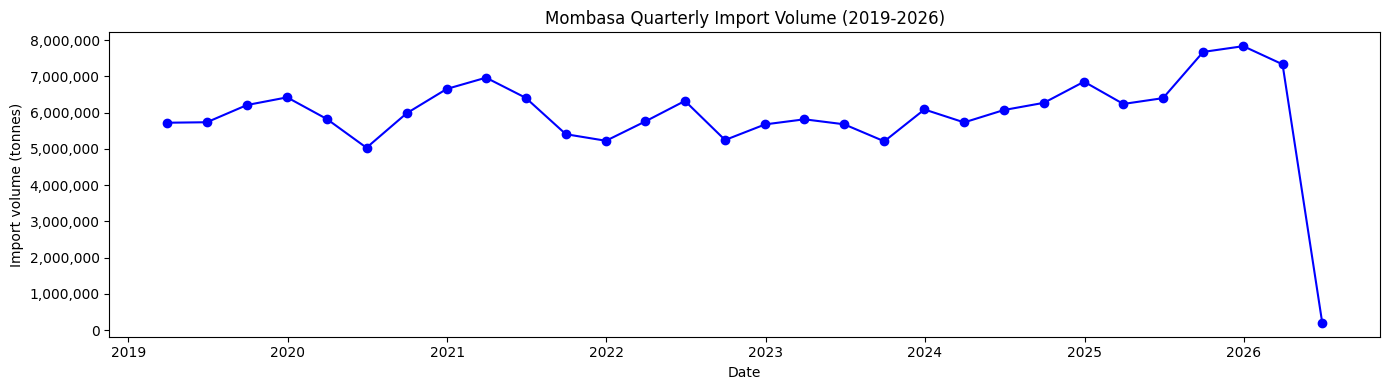

In [312]:
#plot Mombasa port import volume over time
mombasa = df_port[df_port['portname']=='Mombasa']
mombasa['date'] = pd.to_datetime(mombasa[['year', 'month']].assign(day=1))

# 2. Set that date column as the Index
mombasa = mombasa.set_index('date')

# 3.resampling
df_quarterly = mombasa['import'].resample('Q').sum()

plt.figure(figsize=(14,4))
plt.plot(df_quarterly, color='blue', marker='o')
plt.title('Mombasa Quarterly Import Volume (2019-2026)')
plt.xlabel('Date')
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
plt.ylabel('Import volume (tonnes)')
plt.tight_layout()
plt.show()

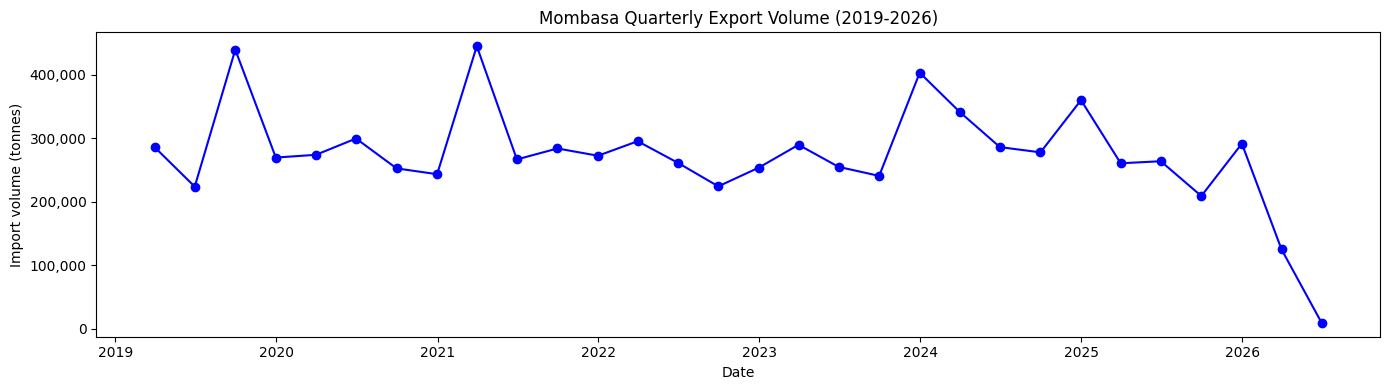

In [313]:
#plot Mombasa port export volume over time
mombasa = df_port[df_port['portname']=='Mombasa']
mombasa['date'] = pd.to_datetime(mombasa[['year', 'month']].assign(day=1))

# 2. Set that date column as the Index
mombasa = mombasa.set_index('date')

# 3.resampling
df_quarterly_mombasa_export = mombasa['export'].resample('Q').sum()

plt.figure(figsize=(14,4))
plt.plot(df_quarterly_mombasa_export, color='blue', marker='o')
plt.title('Mombasa Quarterly Export Volume (2019-2026)')
plt.xlabel('Date')
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
plt.ylabel('Import volume (tonnes)')
plt.tight_layout()
plt.show()

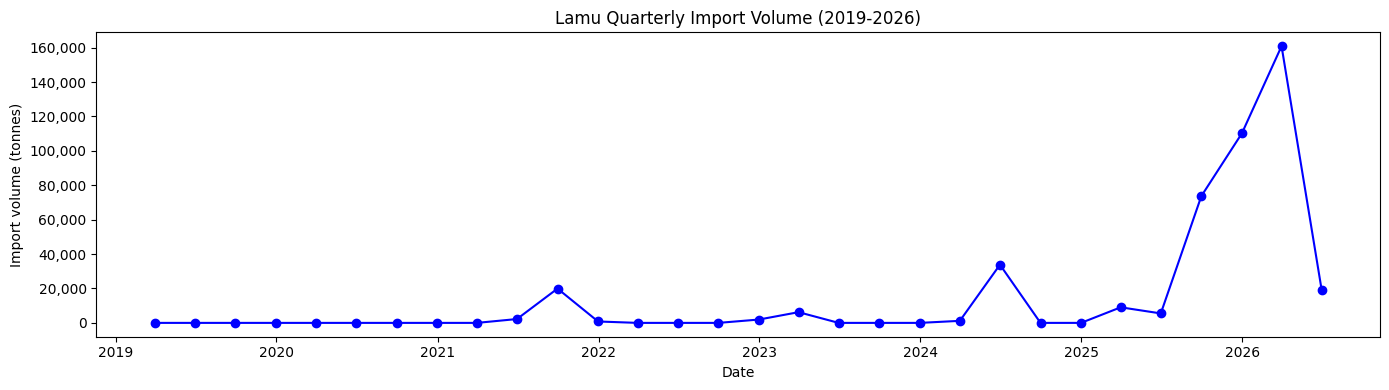

In [314]:
#plot Lamu port import volume over time
lamu = df_port[df_port['portname']=='Lamu']
lamu['date'] = pd.to_datetime(lamu[['year', 'month']].assign(day=1))

# 2. Set that date column as the Index
lamu = lamu.set_index('date')

# 3.resampling
df_quarterly_lamu = lamu['import'].resample('Q').sum()

plt.figure(figsize=(14,4))
plt.plot(df_quarterly_lamu, color='blue', marker='o')
plt.title('Lamu Quarterly Import Volume (2019-2026)')
plt.xlabel('Date')
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
plt.ylabel('Import volume (tonnes)')
plt.tight_layout()
plt.show()

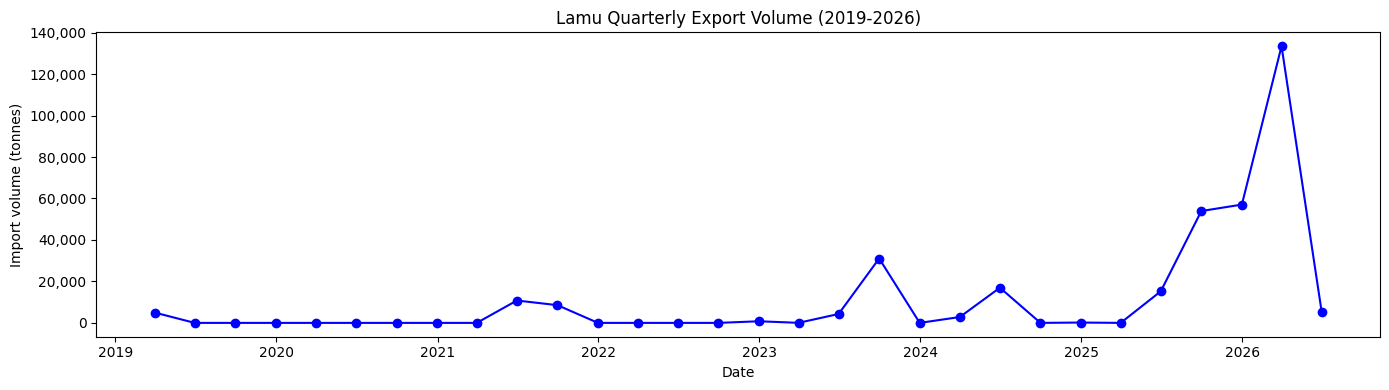

In [315]:
#plot Lamu port export volume over time
lamu = df_port[df_port['portname']=='Lamu']
lamu['date'] = pd.to_datetime(lamu[['year', 'month']].assign(day=1))

# 2. Set that date column as the Index
lamu = lamu.set_index('date')

# 3.resampling
df_quarterly_export = lamu['export'].resample('Q').sum()

plt.figure(figsize=(14,4))
plt.plot(df_quarterly_export, color='blue', marker='o')
plt.title('Lamu Quarterly Export Volume (2019-2026)')
plt.xlabel('Date')
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
plt.ylabel('Import volume (tonnes)')
plt.tight_layout()
plt.show()

## 2.3 Understanding Vessel Waiting Time

In [316]:
df_wait.head()

,Week,Period,Average in Hours,Median in Hours,Count
0,12,18 March 2026 - 24 March 2026,70.67,39.0,3
1,11,11 March 2026 - 17 March 2026,99.63,116.0,8
2,10,04 March 2026 - 10 March 2026,88.00,91.0,8
3,9,25 February 2026 - 03 March 2026,88.78,91.0,9
4,8,18 February 2026 - 24 February 2026,60.50,48.0,4


In [317]:
print(f"The Vessel waiting time dataset has {df_wait.shape[0]} rows and {df_wait.shape[1]} columns")

The Vessel waiting time dataset has 245 rows and 5 columns


In [318]:
#check database datatypes
df_wait.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 245 entries, 0 to 244
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Week              245 non-null    int64  
 1   Period            245 non-null    object 
 2   Average in Hours  245 non-null    float64
 3   Median in Hours   245 non-null    float64
 4   Count             245 non-null    int64  
dtypes: float64(2), int64(2), object(1)
memory usage: 9.7+ KB


In [319]:
#check the average vessel waiting time
df_wait['Average in Hours'].describe()

count    245.000000
mean      43.634939
std       23.998491
min        4.000000
25%       24.000000
50%       36.000000
75%       51.430000
max      152.000000
Name: Average in Hours, dtype: float64

Vessel waiting time ranges from 4 hours to 152 hours

In [320]:
#Congestion analysis
threshold = 72 
total_weeks_above_threshold = (df_wait['Average in Hours'] > threshold).sum()
total_weeks = len(df_wait)
print(f'Vessel waiting time threshold: {threshold}')
print(f'{total_weeks_above_threshold} weeks out of {total_weeks} weeks above threshold. Which is roughly { total_weeks_above_threshold/total_weeks*100:.1f}%')

Vessel waiting time threshold: 72
23 weeks out of 245 weeks above threshold. Which is roughly 9.4%


In [321]:
#worst week
worst_week = df_wait.nlargest(5, 'Average in Hours')
worst_week

,Week,Period,Average in Hours,Median in Hours,Count
27,27,02 July 2025 - 08 July 2025,152.0,152.0,1
24,32,06 August 2025 - 12 August 2025,148.0,148.0,2
30,19,07 May 2025 - 13 May 2025,143.5,143.5,2
20,43,22 October 2025 - 28 October 2025,142.0,142.0,1
39,39,25 September 2024 - 01 October 2024,126.0,120.0,8


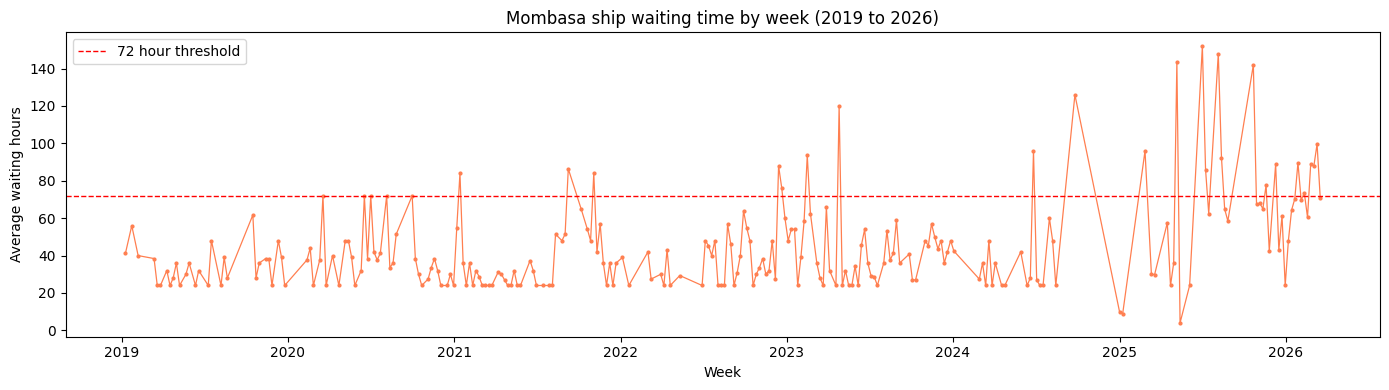

In [322]:
#Congestion peak analysis

# parse the date just for plotting
df_wait_plot = df_wait.copy()
df_wait_plot['week_start'] = df_wait_plot['Period'].apply(
    lambda x: pd.to_datetime(x.split(' - ')[0].strip(), format='%d %B %Y')
)
df_wait_plot = df_wait_plot.sort_values('week_start')

plt.figure(figsize=(14, 4))
plt.plot(df_wait_plot['week_start'], df_wait_plot['Average in Hours'],
         linewidth=0.9, color='coral', marker='o', markersize=2)
plt.axhline(y=72, color='red', linestyle='--', linewidth=1, label='72 hour threshold')
plt.title('Mombasa ship waiting time by week (2019 to 2026)')
plt.xlabel('Week')
plt.ylabel('Average waiting hours')
plt.legend()
plt.tight_layout()
plt.show()

## 2.4 Understanding Vessel Turn Around Time
This dataset contains the average total time spent inside the port.This includes waiting time plus loading and unloading time. 
A high turn around time means the port is slow even after berthing

In [323]:
print(f"The Vessel waiting time dataset has {df_turn.shape[0]} rows and {df_turn.shape[1]} columns")

The Vessel waiting time dataset has 241 rows and 5 columns


In [324]:
#sample view
df_turn.head()

,Week,Period,Average in Hours,Median in Hours,Count
0,12,18 March 2026 - 24 March 2026,108.00,108.0,1
1,11,11 March 2026 - 17 March 2026,122.25,128.5,4
2,10,04 March 2026 - 10 March 2026,124.80,134.0,5
3,9,25 February 2026 - 03 March 2026,142.33,143.0,3
4,8,18 February 2026 - 24 February 2026,118.00,118.0,2


In [325]:
#check database datatypes
df_turn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 241 entries, 0 to 240
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Week              241 non-null    int64  
 1   Period            241 non-null    object 
 2   Average in Hours  241 non-null    float64
 3   Median in Hours   241 non-null    float64
 4   Count             241 non-null    int64  
dtypes: float64(2), int64(2), object(1)
memory usage: 9.5+ KB


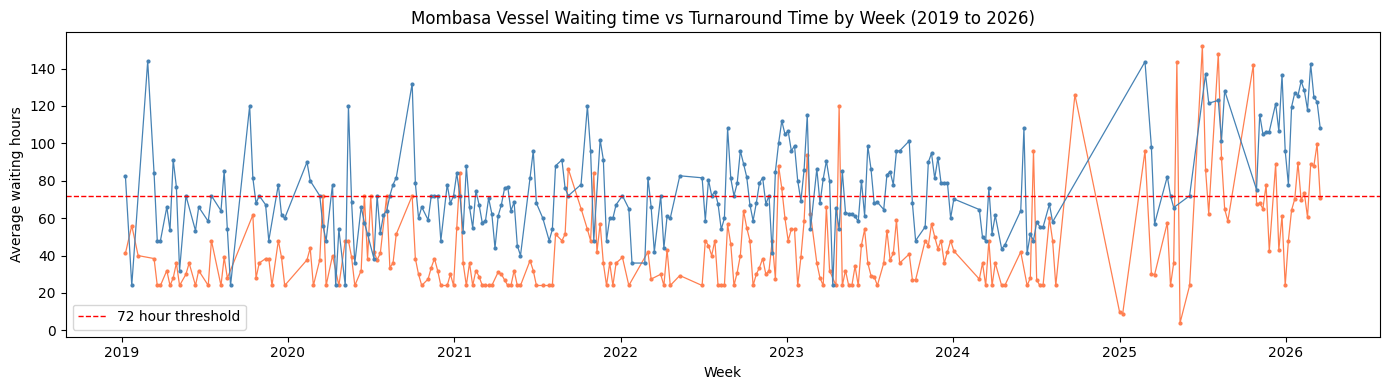

In [326]:
#waiting time vs turn around time

df_wait_plot2 = df_wait.copy()
df_wait_plot2['week_start'] = df_wait_plot2['Period'].apply(
    lambda x: pd.to_datetime(x.split(' - ')[0].strip(), format='%d %B %Y')
)
df_wait_plot2 = df_wait_plot2.sort_values('week_start')

df_turn_plot = df_turn.copy()
df_turn_plot['week_start'] = df_turn_plot['Period'].apply(
    lambda x: pd.to_datetime(x.split(' - ')[0].strip(), format='%d %B %Y')
)
df_turn_plot = df_turn_plot.sort_values('week_start')


plt.figure(figsize=(14, 4))
plt.plot(df_wait_plot2['week_start'], df_wait_plot2['Average in Hours'],
         linewidth=0.9, color='coral', marker='o', markersize=2)
plt.plot(df_turn_plot['week_start'], df_turn_plot['Average in Hours'],
         linewidth=0.9, color='steelblue', marker='o', markersize=2)
plt.axhline(y=72, color='red', linestyle='--', linewidth=1, label='72 hour threshold')
plt.title('Mombasa Vessel Waiting time vs Turnaround Time by Week (2019 to 2026)')
plt.xlabel('Week')
plt.ylabel('Average waiting hours')
plt.legend()
plt.tight_layout()
plt.show()

# 3 Data Cleaning
From the data we have identified
 - period column in waiting and turn around time dataset is a string
 - Date column in port activities dataset is a string with timezone
 - week numbers repeat every year
 - port activities are daily and need to be aggregated to weekly
 - turn around time and waiting time dataset needs to be merged
 - missing weeks needs to be handled



### Fix port activity date column

In [327]:

df_port['date'] = pd.to_datetime(df_port['date'], utc=True).dt.normalize()
df_port['date'] = df_port['date'].dt.tz_localize(None) 
# remove timezone info
#df_port['date'] = df_port['date'].dt.date

print("After sample:", df_port['date'].head(3))
print("Data type now:", df_port['date'].dtype)

After sample: 0   2026-04-03
1   2026-04-03
2   2026-04-02
Name: date, dtype: datetime64[ns]
Data type now: datetime64[ns]


### Separate Mombasa and Lamu

In [328]:
df_mombasa = df_port[df_port['portname'] == 'Mombasa'].copy()
df_lamu    = df_port[df_port['portname'] == 'Lamu'].copy()

# Always sort time series data by date
df_mombasa = df_mombasa.sort_values('date').reset_index(drop=True)
df_lamu    = df_lamu.sort_values('date').reset_index(drop=True)

print(f"Mombasa rows: {len(df_mombasa)}")
print(f"Lamu rows:    {len(df_lamu)}")

Mombasa rows: 2650
Lamu rows:    2650


### Check if any dates are missing in Mombasa

In [329]:
missing_dates = df_mombasa.isna().sum()
if missing_dates.sum() > 0:
    print("\nMissing dates:")
    print(missing_dates)

### Add week_id to Mombasa daily data

ISO week runs Monday to Sunday which is the standard
week_id combines year and week so 2025-W12 and 2026-W12 are different

In [330]:
df_mombasa['iso_year']   = df_mombasa['date'].dt.isocalendar().year.astype(int)
df_mombasa['iso_week']   = df_mombasa['date'].dt.isocalendar().week.astype(int)
df_mombasa['week_id']    = (df_mombasa['iso_year'].astype(str) + '-W' +
                            df_mombasa['iso_week'].astype(str).str.zfill(2))
df_mombasa['week_start'] = df_mombasa['date'] - pd.to_timedelta(
                            df_mombasa['date'].dt.dayofweek, unit='D')

print("Sample week_id values:")
print(df_mombasa[['date', 'iso_year', 'iso_week', 'week_id', 'week_start']].head(10).to_string())

Sample week_id values:
        date  iso_year  iso_week   week_id week_start
0 2019-01-01      2019         1  2019-W01 2018-12-31
1 2019-01-02      2019         1  2019-W01 2018-12-31
2 2019-01-03      2019         1  2019-W01 2018-12-31
3 2019-01-04      2019         1  2019-W01 2018-12-31
4 2019-01-05      2019         1  2019-W01 2018-12-31
5 2019-01-06      2019         1  2019-W01 2018-12-31
6 2019-01-07      2019         2  2019-W02 2019-01-07
7 2019-01-08      2019         2  2019-W02 2019-01-07
8 2019-01-09      2019         2  2019-W02 2019-01-07
9 2019-01-10      2019         2  2019-W02 2019-01-07


### Aggregate Mombasa from daily to weekly

The waiting time and turn around time are weekly

- For cargo volumes we SUM - total tonnes moved that week 
- For port calls we SUM - total vessel arrivals that week
- days_with_data counts how many days in that week had records
- any week with less than 7 days_with_data is an incomplete week

In [331]:

df_mombasa_weekly = df_mombasa.groupby(
    ['week_id', 'week_start']
).agg(
    total_import        = ('import', 'sum'),
    total_export        = ('export', 'sum'),
    total_portcalls     = ('portcalls', 'sum'),
    portcalls_container = ('portcalls_container', 'sum'),
    portcalls_tanker    = ('portcalls_tanker', 'sum'),
    portcalls_dry_bulk  = ('portcalls_dry_bulk', 'sum'),
    portcalls_roro      = ('portcalls_roro', 'sum'),
    portcalls_general   = ('portcalls_general_cargo', 'sum'),
    import_container    = ('import_container', 'sum'),
    import_tanker       = ('import_tanker', 'sum'),
    import_dry_bulk     = ('import_dry_bulk', 'sum'),
    days_with_data      = ('date', 'count')
).reset_index()

df_mombasa_weekly = df_mombasa_weekly.sort_values('week_start').reset_index(drop=True)

print(f"Weekly rows after aggregation: {len(df_mombasa_weekly)}")
print(f"\nSample:")
print(df_mombasa_weekly.head(5).to_string())

Weekly rows after aggregation: 379

Sample:
    week_id week_start  total_import  total_export  total_portcalls  portcalls_container  portcalls_tanker  portcalls_dry_bulk  portcalls_roro  portcalls_general  import_container  import_tanker  import_dry_bulk  days_with_data
0  2019-W01 2018-12-31        518968         10009               17                    6                 6                   5               0                  0             52224         257568           209176               6
1  2019-W02 2019-01-07        556906         16083               27                   11                 6                   8               2                  0            115433         136903           303591               7
2  2019-W03 2019-01-14        379268         12949               26                   10                 5                   3               6                  2            134488         112431           122950               7
3  2019-W04 2019-01-21        353303        

### Fix the Period column in waiting and turn around time data

"18 March 2026 - 24 March 2026" is a text string

In [332]:
df_wait_clean = df_wait.copy()

df_wait_clean['week_start'] = df_wait_clean['Period'].apply(
    lambda x: pd.to_datetime(x.split(' - ')[0].strip(), format='%d %B %Y')
)

df_wait_clean['iso_year'] = df_wait_clean['week_start'].dt.isocalendar().year.astype(int)
df_wait_clean['iso_week'] = df_wait_clean['week_start'].dt.isocalendar().week.astype(int)
df_wait_clean['week_id']  = (df_wait_clean['iso_year'].astype(str) + '-W' +
                              df_wait_clean['iso_week'].astype(str).str.zfill(2))

# Rename columns to clean names
df_wait_clean = df_wait_clean.rename(columns={
    'Average in Hours': 'wait_avg_hours',
    'Median in Hours':  'wait_median_hours',
    'Count':            'wait_ship_count'
})

df_wait_clean = df_wait_clean.sort_values('week_start').reset_index(drop=True)

print(f"Date range: {df_wait_clean['week_start'].min()} to {df_wait_clean['week_start'].max()}")
print(f"\nSample:")
print(df_wait_clean[['week_id', 'week_start', 'wait_avg_hours', 'wait_ship_count']].head(5))

Date range: 2019-01-09 00:00:00 to 2026-03-18 00:00:00

Sample:
    week_id week_start  wait_avg_hours  wait_ship_count
0  2019-W02 2019-01-09           41.14               14
1  2019-W04 2019-01-23           56.00                3
2  2019-W06 2019-02-06           40.00                3
3  2019-W11 2019-03-13           38.40                5
4  2019-W12 2019-03-20           24.00                2


In [333]:

df_turn_clean = df_turn.copy()

df_turn_clean['week_start'] = df_turn_clean['Period'].apply(
    lambda x: pd.to_datetime(x.split(' - ')[0].strip(), format='%d %B %Y')
)

df_turn_clean['iso_year'] = df_turn_clean['week_start'].dt.isocalendar().year.astype(int)
df_turn_clean['iso_week'] = df_turn_clean['week_start'].dt.isocalendar().week.astype(int)
df_turn_clean['week_id']  = (df_turn_clean['iso_year'].astype(str) + '-W' +
                              df_turn_clean['iso_week'].astype(str).str.zfill(2))

df_turn_clean = df_turn_clean.rename(columns={
    'Average in Hours': 'turnaround_avg_hours',
    'Median in Hours':  'turnaround_median_hours',
    'Count':            'turnaround_ship_count'
})

df_turn_clean = df_turn_clean.sort_values('week_start').reset_index(drop=True)

print(f"Date range: {df_turn_clean['week_start'].min()} to {df_turn_clean['week_start'].max()}")
print(f"Total weeks: {len(df_turn_clean)}")

Date range: 2019-01-09 00:00:00 to 2026-03-18 00:00:00
Total weeks: 241


### Merge all three datasets and check for missing values

We join on week_id

In [334]:
wait_cols = ['week_id', 'wait_avg_hours', 'wait_median_hours', 'wait_ship_count']
turn_cols = ['week_id', 'turnaround_avg_hours', 'turnaround_median_hours', 'turnaround_ship_count']

df_merged = df_mombasa_weekly.merge(df_wait_clean[wait_cols], on='week_id', how='left')
df_merged = df_merged.merge(df_turn_clean[turn_cols], on='week_id', how='left')

print(f"Merged rows: {len(df_merged)}")
print(f"\nMissing values after merge:")
print(df_merged.isnull().sum())

Merged rows: 379

Missing values after merge:
week_id                      0
week_start                   0
total_import                 0
total_export                 0
total_portcalls              0
portcalls_container          0
portcalls_tanker             0
portcalls_dry_bulk           0
portcalls_roro               0
portcalls_general            0
import_container             0
import_tanker                0
import_dry_bulk              0
days_with_data               0
wait_avg_hours             134
wait_median_hours          134
wait_ship_count            134
turnaround_avg_hours       138
turnaround_median_hours    138
turnaround_ship_count      138
dtype: int64


### Fill missing waiting and turnaround values
Some port activity weeks have no matching waiting time record
We will forward fill(carry the last known value forward), then backward fill(for any gaps at the very start)

In [335]:
missing_before = df_merged['wait_avg_hours'].isnull().sum()

fill_cols = [
    'wait_avg_hours', 'wait_median_hours', 'wait_ship_count',
    'turnaround_avg_hours', 'turnaround_median_hours', 'turnaround_ship_count'
]

for col in fill_cols:
    df_merged[col] = df_merged[col].ffill().bfill()

missing_after = df_merged['wait_avg_hours'].isnull().sum()

print(f"Missing wait_avg_hours before fill: {missing_before}")
print(f"Missing wait_avg_hours after fill:  {missing_after}")


Missing wait_avg_hours before fill: 134
Missing wait_avg_hours after fill:  0


### Creating the target variable

This is thr column our model will learn to predict
logic: if next week's average waiting time > 72 hours = congestion
We shift by -1 to look one week ahead

In [336]:
THRESHOLD = df_merged['wait_avg_hours'].quantile(0.75)  # hours — we will validate this

df_merged['next_week_wait']        = df_merged['wait_avg_hours'].shift(-1)
df_merged['congestion_next_week']  = (df_merged['next_week_wait'] > THRESHOLD).astype(int)

# Drop the last row — no label possible for the most recent week
df_merged = df_merged[:-1].copy()

total     = len(df_merged)
congested = df_merged['congestion_next_week'].sum()
normal    = total - congested

print(f"Total labelled weeks : {total}")
print(f"Congestion (label=1) : {congested} ({congested/total*100:.1f}%)")
print(f"Normal     (label=0) : {normal} ({normal/total*100:.1f}%)")
print(f"\nThreshold used: {THRESHOLD} hours")

Total labelled weeks : 378
Congestion (label=1) : 92 (24.3%)
Normal     (label=0) : 286 (75.7%)

Threshold used: 51.43 hours


In [337]:
# Cell 51: Save the clean merged dataset
# We save to data/processed/ — never overwrite the raw files
# This file is the input for feature engineering

import os
os.makedirs('data/processed', exist_ok=True)

df_merged.to_csv('data/processed/mombasa_weekly_clean.csv', index=False)

print(f"Saved: data/processed/mombasa_weekly_clean.csv")
print(f"Shape: {df_merged.shape}")
print(f"\nFinal columns:")
for col in df_merged.columns:
    print(f"  {col}")

Saved: data/processed/mombasa_weekly_clean.csv
Shape: (378, 22)

Final columns:
  week_id
  week_start
  total_import
  total_export
  total_portcalls
  portcalls_container
  portcalls_tanker
  portcalls_dry_bulk
  portcalls_roro
  portcalls_general
  import_container
  import_tanker
  import_dry_bulk
  days_with_data
  wait_avg_hours
  wait_median_hours
  wait_ship_count
  turnaround_avg_hours
  turnaround_median_hours
  turnaround_ship_count
  next_week_wait
  congestion_next_week
